# Week 1 — Fundamentos em GIS (notebook auxiliar)

Este notebook reúne, em um único arquivo `.ipynb`, todo o conteúdo (texto e código) das páginas da Semana 1 do curso -- pensado pra quem prefere rodar tudo direto no Jupyter/Colab em vez de acompanhar pelo site em Quarto.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/fundamentals_gis_rs/week1/AUX_week1.ipynb)

::: {.callout-note}
Gerado automaticamente a partir de `crs_and_projections.qmd` e `spatial_analysis_of_vectors.qmd`. Se algo aqui estiver desatualizado, as páginas do site são a fonte da verdade.
:::

---

# Sistemas de Coordenadas de Referência e Projeções
### Como representar um planeta redondo numa tela plana?

*Emanuel Goulart — today*


In [12]:
#| include: false
import numpy as np #pip install numpy matplotlib geopandas pyproj
import matplotlib.pyplot as plt
import geopandas as gpd
import pyproj
import cartopy.crs as ccrs #pip install cartopy
import cartopy.feature as cfeature
import geobr
import h3
from shapely.geometry import Polygon

::: {.callout-tip appearance="simple"}
Prefere rodar tudo num notebook em vez de acompanhar pelo site? [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/fundamentals_gis_rs/week1/AUX_week1.ipynb) abre o `AUX_week1.ipynb` -- todo o conteúdo (texto e código) da Semana 1 num único notebook.
:::

## Qual o nosso sistema de referência? Todos os pontos precisam de contexto?

Uma ponto coordenada como `(-27, -48)` não significa nada sozinho. Precisamos saber se estamos falando de graus ou metros, a qual sistema de coordenadas esse ponto se refere? E podemos mergulhar mais a fundo sobre qual o elipsoide estamos usando?

### Motivação

- Como localizar objetos na Terra?
- Onde definimos o centro de um eixo?
- O que define norte e sul?

::: {.callout-tip appearance="simple"}
Assim como "10" não quer dizer nada sem uma unidade (10 metros? 10 reais? 10 graus?), uma coordenada não quer dizer nada sem um **Sistema de Referência de Coordenadas** (CRS). O contexto serve para definir a origem, a unidade e o modelo da Terra utilizado em nossa representação.
:::

## A Terra não é uma esfera perfeita

![Imagem recente do planeta Terra capturada pela última missão Artemis II. Fonte: Artemis II. NASA. 02-04-2026.](images/artemis2.jpg){fig-align="center"}

Um sistema de coordenadas (CRS) define como as representações gráficas nas ferramentas GIS estão localizadas e posicionadas no planeta Terra. Portanto, se partimos da presunção de que a Terra é uma esfera perfeita, poderíamos correlacionar esse ponto com a perspectiva de um ponto tangenciando uma esfera.

In [13]:
import numpy as np
import plotly.graph_objects as go

R = 1.0

theta = np.pi / 4
phi = np.pi / 3

x0 = R * np.sin(theta) * np.cos(phi)
y0 = R * np.sin(theta) * np.sin(phi)
z0 = R * np.cos(theta)

u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 80)

x = R * np.outer(np.cos(u), np.sin(v))
y = R * np.outer(np.sin(u), np.sin(v))
z = R * np.outer(np.ones_like(u), np.cos(v))

sphere = go.Surface(
    x=x, y=y, z=z,
    opacity=0.4,
    colorscale="Blues",
    showscale=False
)

vector = go.Scatter3d(
    x=[0, x0],
    y=[0, y0],
    z=[0, z0],
    mode="lines+markers",
    line=dict(color="red", width=6),
    marker=dict(size=4),
    name="vetor r"
)

point = go.Scatter3d(
    x=[x0],
    y=[y0],
    z=[z0],
    mode="markers",
    marker=dict(size=6, color="red"),
)

L = 1.5 * R

axes = [
    go.Scatter3d(x=[-L, L], y=[0, 0], z=[0, 0],
                 mode="lines", line=dict(color="black", width=4)),
    go.Scatter3d(x=[0, 0], y=[-L, L], z=[0, 0],
                 mode="lines", line=dict(color="black", width=4)),
    go.Scatter3d(x=[0, 0], y=[0, 0], z=[-L, L],
                 mode="lines", line=dict(color="black", width=4)),
]

layout = go.Layout(
    scene=dict(
        xaxis=dict(title="X", showbackground=True),
        yaxis=dict(title="Y", showbackground=True),
        zaxis=dict(title="Z", showbackground=True),
        aspectmode="cube"
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig = go.Figure(data=[sphere, vector, point] + axes, layout=layout)
fig.show()

Bom... considerando que a Terra é redonda. Contudo, os dados mostram que o formato da Terra não é exatamente esférico. Sendo ela denominada como um um **elipsoide de revolução** ou **geóide**. Contudo, nem todo elipsóide se ajusta igualmente em todos os cantos do globo, dessa forma, um elipsóide ajusta para a América do Sul pode ser diferente de um ajustado para a Ásia central. 
Assim, cada um desses ajustes ocasiona um **Datum**. Datum é um modelo matemático que ancora o sistema de coordenadas na Terra. É exatamente por isso que existem vários "WGS84 da vida": cada datum é uma tentativa diferente de responder "onde exatamente essa esfera imaginária encosta no planeta real?

![Campo gravitacional terrestre (Geoide). Fonte: ESA](images/geoide.webp){fig-align="center"}

[Animação da Representação do Geoide](https://www.esa.int/ESA_Multimedia/Videos/2021/03/The_geoid) — ESA

Portanto, esse sistema de referência define padrões e afinidades que permitem localizar um ponto em qualquer lugar da Terra. 


::: {.callout-note appearance="simple"}
## Conversão vs. transformação

- **Conversão** : trocar de projeção mantendo o mesmo datum. Pura matemática, sem perda, 100% reversível.
- **Transformação** : trocar de datum. Envolve modelos ajustados empiricamente e pode introduzir alguns metros de incerteza. 
:::

## CRS Geográfico vs. Projetado

| | **CRS Geográfico** | **CRS Projetado** |
|---|---|---|
| Unidade | graus (°) | metros (normalmente) |
| Exemplo | WGS84 (EPSG:4326), SIRGAS2000 (EPSG:4674) | SIRGAS2000 / UTM 22S (EPSG:31982) |
| Bom para | dado global, web mapping, GPS | medir distância/área, análise local |
| Problema | 1° de longitude ≠ 1° de latitude em distância real | só é preciso perto do seu centro/zona |

Um grau de latitude vale sempre ~111 km em qualquer lugar do planeta. Um grau de **longitude**, não — vale ~111 km no equador e encolhe até virar zero nos polos. É por isso que fazer conta de distância/área direto em graus dá resultado errado (a gente mostra isso mais abaixo, na prática).

::: {.callout-important appearance="simple"}
Não existe projeção sem distorção. Toda projeção sacrifica alguma propriedade, seja ela área, ângulo (forma), distância, etc. A pergunta que nos cabe é qual a projeção para a análise que desejamos executar? Contando que não existe uma projeção "correta". 
:::


## Planet Terra em três projeções diferentes.

Os mesmos dados, formas muito diferentes, a projeção é uma decisão analítica, não apenas estética, quiçá política.

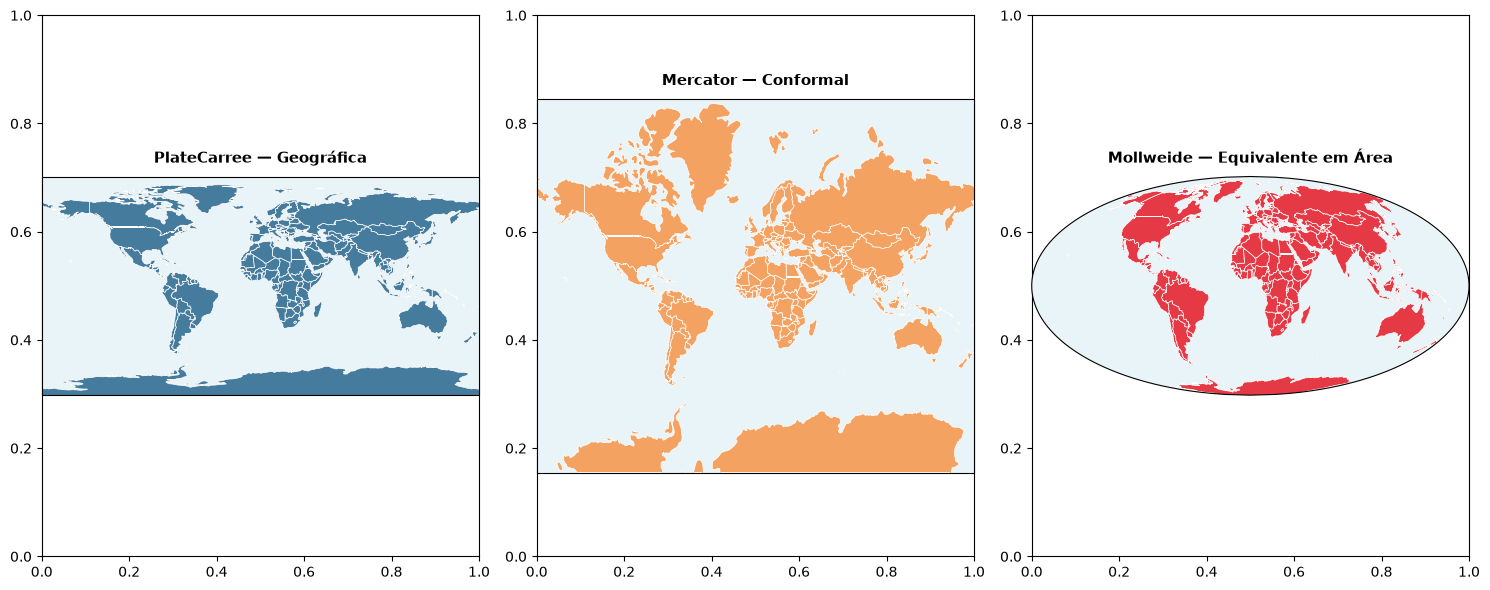

In [14]:
#| label: fig-africa
#| fig-cap: "O mundo em três projeções: PlateCarree (geográfica), Mercator e Mollweide (equivalente em área)."

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

projections = [
    (ccrs.PlateCarree(),   'PlateCarree — Geográfica',          '#457b9d'),
    (ccrs.Mercator(),      'Mercator — Conformal',               '#f4a261'),
    (ccrs.Mollweide(),     'Mollweide — Equivalente em Área',  '#e63946'),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 6),
    subplot_kw={'projection': None}
)

for i, (proj, title, color) in enumerate(projections):
    ax = fig.add_subplot(1, 3, i + 1, projection=proj)
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor='#e8f4f8')
    ax.add_feature(cfeature.LAND,  facecolor='#f0f0f0')
    for geom in world.geometry:
        ax.add_geometries(
            [geom], ccrs.PlateCarree(),
            facecolor=color, edgecolor='white', linewidth=0.5
        )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

![Novo mapa mundi divulgado pelo Governo do Brasil, 2026. Fonte: IBGE](images/ibge-mapa-mundi.webp){fig-align="center"}


### Fun Fact

A bandeira da ONU é uma projeção equidistante.

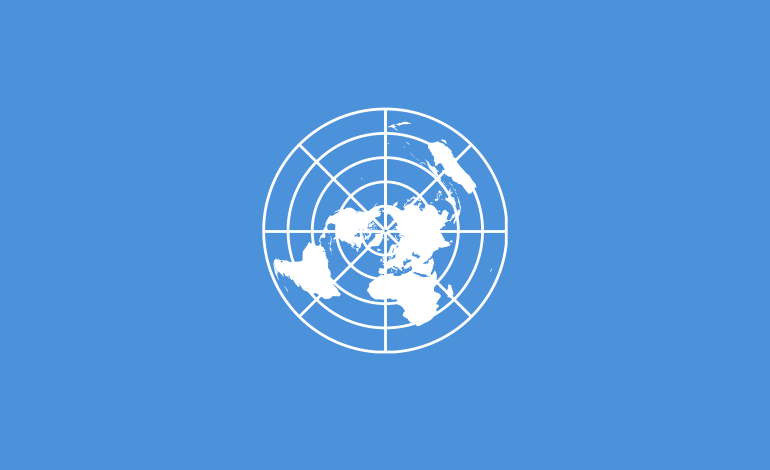

In [15]:
from matplotlib.patches import PathPatch
import matplotlib.path
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib.transforms import Bbox, BboxTransform
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# When drawing the flag, we can either use white filled land, or be a little
# more fancy and use the Natural Earth shaded relief imagery.
filled_land = True


blue = '#4b92db'

# We're drawing a flag with a 3:5 aspect ratio.
fig = plt.figure(figsize=[7.5, 4.5], facecolor=blue)
# Put a blue background on the figure.
blue_background = PathPatch(matplotlib.path.Path.unit_rectangle(),
                            transform=fig.transFigure, color=blue,
                            zorder=-1)
fig.patches.append(blue_background)

# Set up the Azimuthal Equidistant and Plate Carree projections
# for later use.
az_eq = ccrs.AzimuthalEquidistant(central_latitude=90)
pc = ccrs.PlateCarree()

# Pick a suitable location for the map (which is in an Azimuthal
# Equidistant projection).
ax = fig.add_axes([0.25, 0.24, 0.5, 0.54], projection=az_eq)

# The background patch is not needed in this example.
ax.patch.set_facecolor('none')
# The Axes frame produces the outer meridian line.
for spine in ax.spines.values():
    spine.update({'edgecolor': 'white', 'linewidth': 2})

# We want the map to go down to -60 degrees latitude.
ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())

# Importantly, we want the axes to be circular at the -60 latitude
# rather than cartopy's default behaviour of zooming in and becoming
# square.
_, patch_radius = az_eq.transform_point(0, -60, pc)
circular_path = matplotlib.path.Path.circle(0, patch_radius)
ax.set_boundary(circular_path)

if filled_land:
    ax.add_feature(
        cfeature.LAND, facecolor='white', edgecolor='none')
else:
    ax.stock_img()

gl = ax.gridlines(crs=pc, linewidth=2, color='white', linestyle='-')
# Meridians every 45 degrees, and 4 parallels.
gl.xlocator = matplotlib.ticker.FixedLocator(np.arange(-180, 181, 45))
parallels = np.arange(-30, 70, 30)
gl.ylocator = matplotlib.ticker.FixedLocator(parallels)


plt.show()

## Projeções - Sistema UTM - Universal Transverse Mercator

O Sistema de Coordenadas Universal Transverso de Mercator (UTM) tem sua origem no equador em uma longitude específica. Para diminuir distorções, o mundo é dividido em 60 zonas com 6 graus de comprimento em longitude. As zonas são numeradas entre 1 e 60, em ordem respectiva de oeste a leste.

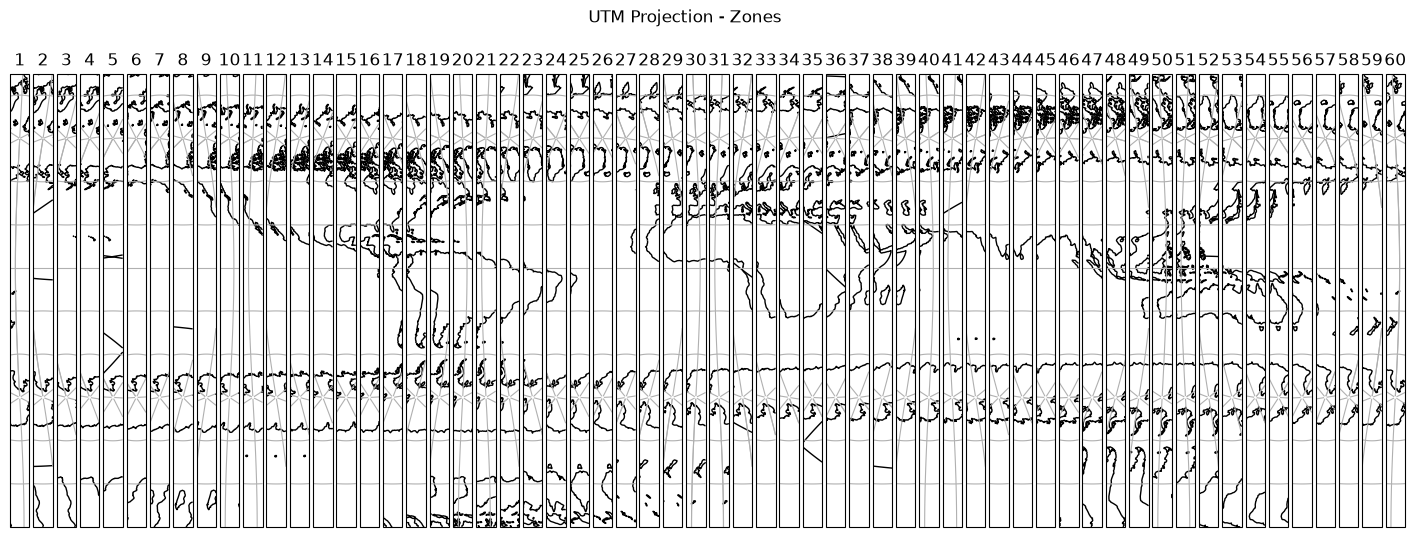

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Create a list of integers from 1 - 60
zones = range(1, 61)

# Create a figure
fig = plt.figure(figsize=(18, 6))

# Loop through each zone in the list
for zone in zones:

    # Add GeoAxes object with specific UTM zone projection to the figure
    ax = fig.add_subplot(1, 
                        len(zones), 
                        zone,
                        projection=ccrs.UTM(zone=zone,
                                            southern_hemisphere=True)
                                            )

    # Add coastlines, gridlines and zone number for the subplot
    ax.coastlines(resolution='110m')
    ax.gridlines()
    ax.set_title(zone)

# Add a supertitle for the figure
fig.suptitle("UTM Projection - Zones")

# Display the figure
plt.show()

::: {.callout-note appearance="simple"}
## Nada novo sob o sol

Pequeno gafanhoto sempre existirá algum website ou projeto que alguém já criou e que facilita a sua vida.

- **Mapa UTM** - [UTM MAPA](https://www.dmap.co.uk/utmworld.htm)
- **Matemática por trás** - [UTM Glossario](https://www.tarmacview.com/glossary/utm/) 
- **BOM DEMAIS** - [Diversas projecoes](https://www.geo-projections.com/ )
- **EPSG.IO** - [EPSG - **Brabo dos brabo**](https://epsg.io/)
- **Map4s3** - [Salvador da Patria](https://map4s3.com.br/maps/br_utm/)

:::

## Como podemos reprojetar os dados geoespaciais?

Uma das formas mais clássicas e tradicionais de manipular dados geoespaciais é usando o projeto robusto e estável GDAL.[GDAL-WEBSITE](https://gdal.org/en/stable/). GDAL é a engine rodando por debaixo dos panos de muitos softwares mundo a fora, como por exemplo o nosso querido QGIS. Tudo o que você imagina que é possível fazer, em termos de manipulação de dados geoespaciais como vetores e raster, muito provavelmente alguém já vai ter feito com GDAL. Extremamente completa e poderosa, a biblioteca conta com Open Source Licence e uma comunidade engajada, que promove um dos maiores eventos geoespaciais do mundo: [FOSS4G](https://2026.foss4g.org/en/).

Para ilustrarmos esses conceitos de transformação dos dados e reprojeções, utilizaremos uma engine que trabalha por debaixo dos panos no GDAL para transformar os dados, chamada [PROJ](https://proj.org/en/stable/). Contudo, vamos abordar suas bindings em Python. 

## `pyproj` por baixo dos panos

`pyproj` é a biblioteca Python que fala com o [PROJ](https://proj.org/), o motor de transformação de coordenadas usado por praticamente todo o ecossistema geoespacial (QGIS, GDAL, GeoPandas, Cartopy, e lá vai pedrada). A classe `Transformer` converte um ponto de um CRS para outro:

In [17]:
transformer = pyproj.Transformer.from_crs(
    "EPSG:4326",   # WGS84, geográfico
    "EPSG:31982",  # SIRGAS2000 / UTM zone 22S
    always_xy=True,
)

lon, lat = -30.0330, -51.2300  # Florianópolis
x, y = transformer.transform(lon, lat)
print(f"Geográfico:  {lon:.4f}°, {lat:.4f}°")
print(f"Projetado:   x={x:,.1f} m, y={y:,.1f} m")

Geográfico:  -30.0330°, -51.2300°
Projetado:   x=1,956,237.5 m, y=4,112,626.3 m


Repare: saímos de graus e chegamos em metros a partir de uma origem arbitrária da zona UTM, é isso que uma projeção faz, ponto a ponto.

### Visualizando a distorção

Uma forma direta de *ver* o que uma projeção faz é pegar uma grade regular de meridianos (longitude) e paralelos (latitude) (em graus) e observar como ela fica depois de projetada.

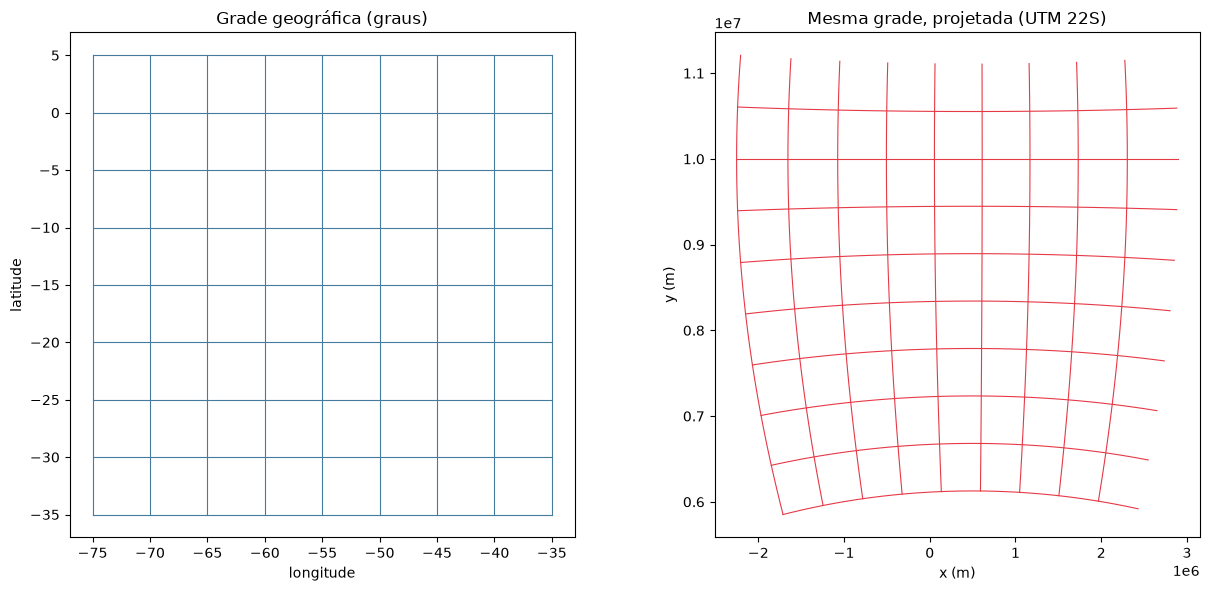

In [18]:
#| label: fig-grid-warp
#| fig-cap: "Uma grade regular de 5° em graus (esquerda) e a mesma grade depois de projetada para uma única zona UTM (direita). Longe do meridiano central da zona, a distorção explode, é exatamente por isso que UTM é dividido em zonas estreitas."

lons = np.arange(-75, -30, 5)
lats = np.arange(-35, 10, 5)

to_utm = pyproj.Transformer.from_crs("EPSG:4326", 
                                    "EPSG:31982", 
                                    always_xy=True
                                    )

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# grade original, em graus
ax = axes[0]
for lon in lons:
    ax.plot([lon] * len(lats), lats, color="#457b9d", linewidth=0.8)
for lat in lats:
    ax.plot(lons, [lat] * len(lons), color="#457b9d", linewidth=0.8)
ax.set_title("Grade geográfica (graus)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_aspect("equal")

# a mesma grade, projetada pra uma única zona UTM (22S)
ax = axes[1]
for lon in lons:
    lat_line = np.linspace(-35, 10, 60)
    x, y = to_utm.transform([lon] * len(lat_line), lat_line)
    ax.plot(x, y, color="#e63946", linewidth=0.8)
for lat in lats:
    lon_line = np.linspace(-75, -30, 60)
    x, y = to_utm.transform(lon_line, [lat] * len(lon_line))
    ax.plot(x, y, color="#e63946", linewidth=0.8)
ax.set_title("Mesma grade, projetada (UTM 22S)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

A grade projetada deforma conforme se afasta do meridiano central da zona 22S. E isso não é é um bug, mas sim a consequência da projeção. Isso nos leva a compreender o fato de UTM ser dividida em 60 zonas estreitas de 6° cada. Dessa forma, cada zona só é precisa perto do seu próprio centro. 

## Visualizando com Cartopy

Os mesmos dados, três projeções, três decisões diferentes sobre a américa do sul:

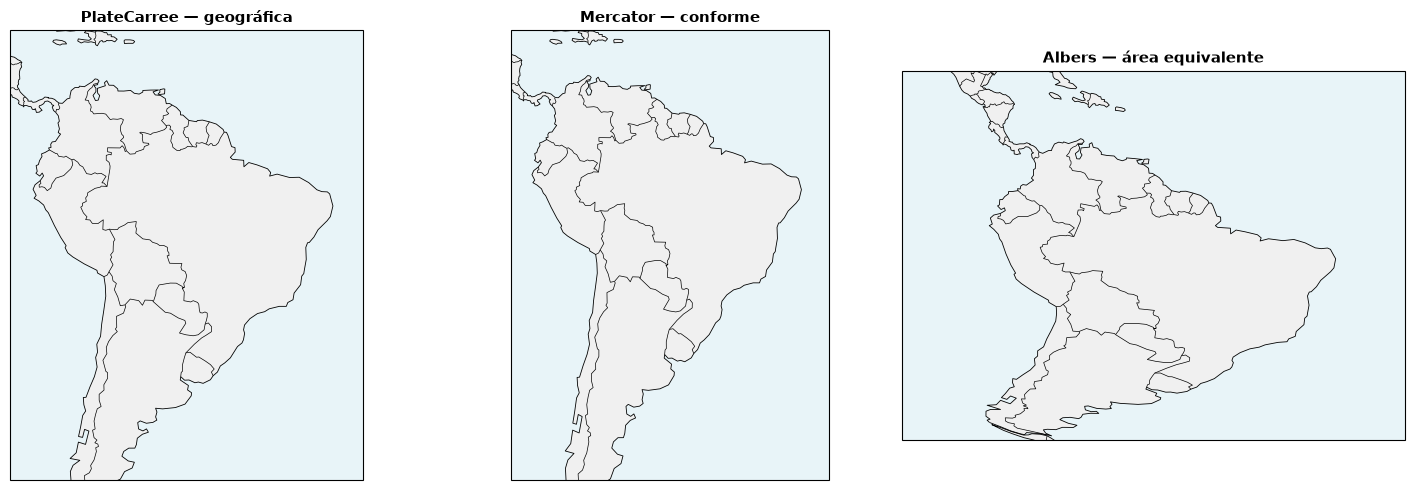

In [19]:
#| label: fig-projections
#| fig-cap: "PlateCarree (geográfica, sem correção nenhuma), Mercator (conforme — preserva ângulos, mas distorce área longe do equador) e Albers Equal Area centrada no Brasil (preserva área)."

projections = [
    (ccrs.PlateCarree(), "PlateCarree — geográfica"),
    (ccrs.Mercator(), "Mercator — conforme"),
    (ccrs.AlbersEqualArea(central_longitude=-50, 
                            central_latitude=-20), "Albers — área equivalente"),
]

fig = plt.figure(figsize=(15, 5))
for i, (proj, title) in enumerate(projections, start=1):
    ax = fig.add_subplot(1, 3, i, projection=proj)
    ax.set_extent([-85, -30, -50, 20], 
                    crs=ccrs.PlateCarree()
                    )
    ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f4f8")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.coastlines(linewidth=0.6)
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

### Aprofundando os mapas geográficos em python
####  Gridlines e rótulos

O [Cartopy](https://cartopy.readthedocs.io/stable/) será nosso carro chefe aqui para realizar mapas estáticos. Ele tem funcionalidades para tudo. Aqui exploraremos como desenhar os meridianos e paralelos com rótulo direto no eixo.

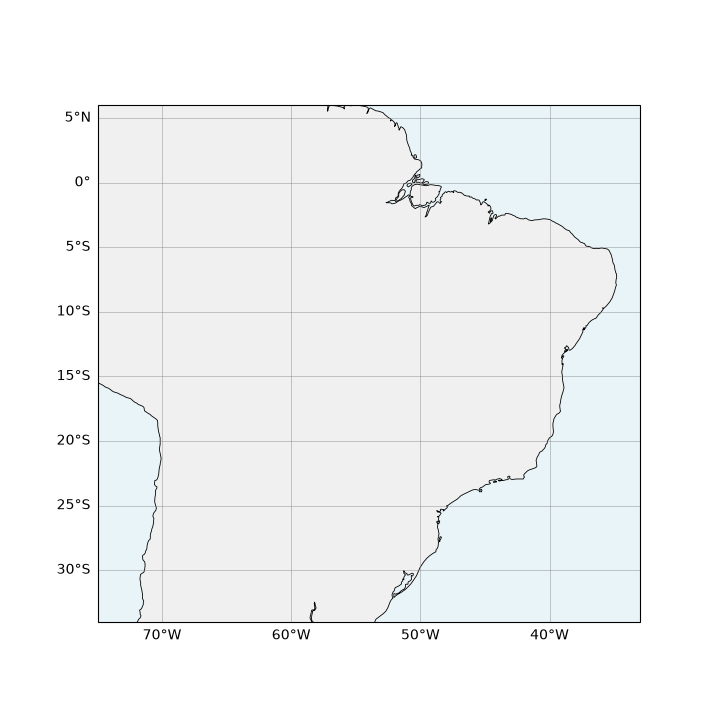

In [20]:
#| label: fig-gridliner
#| fig-cap: "Gridlines com rótulos automáticos de latitude/longitude sobre o Brasil."

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-75, -33, -34, 6], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
ax.add_feature(cfeature.OCEAN, facecolor="#e8f4f8")
ax.coastlines(linewidth=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.6)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Brasil com gridlines rotuladas", fontsize=12, fontweight="bold")
plt.show()

::: {.callout-note appearance="simple"}
TIP: 
- Onde conseguir dados de delineação dos países? 
A referência é sempre utilizar [Natural Earth Data](https://www.naturalearthdata.com/about/).

Geopandas tem uma integração direta com eles no: [Geodatasets](https://geodatasets.readthedocs.io/en/latest/).
No R, a biblioteca é melhor estruturada: [R Natural Earth](https://ropensci.github.io/rnaturalearth/)

:::


## Reprojeção: vetor vs. raster

Quando pensamos nos tipos de dados geoespaciais, a reprojeção dos dois tipos não é a mesma coisa. Quando temos uma matriz de dados (raster) precisamos reprojetar e reamostrar os valores dessa matriz dentro de um novo sistema de coordenadas. 

Olhemos com mais calma: 

- **Vetor** : cada vértice é um ponto, e um ponto vira outro ponto direto pela fórmula de transformação.
- **Raster**: reprojetar significa criar uma grade *nova*, com pixels em posições diferentes, e daí **re-amostrar** (interpolar) os valores originais pra essa grade nova. É mais trabalho computacional e costuma perder um pouco de informação. Então ai vai uma dica: Quando você  estiver trabalhando com dados de vetores e raster, tente, sempre que possível, reprojetar os vetores pro CRS do raster, e não o contrário.

### Vetor: Não existe área em graus. 

Um dos erros mais comuns de quem está começando a manipular dados geoespaciais é calcular a área utilizando um sistema geográfico em graus, ao invés de sua projeção. 

In [21]:
sc = geobr.read_state(code_state="SC", year=2020)

area_graus = sc.geometry.area.iloc[0]          # em graus² -- quer dizer porra nenhuma 

# primeiro se reprojetada para uma projecao UTM na zona da area de interesse 
area_km2 = sc.to_crs(31982).geometry.area.iloc[0] / 1e6  # reprojetado pra metros, depois km²

print(f"Área 'calculada' direto em graus:  {area_graus:.4f} (sem unidade real, inútil)")
print(f"Área depois de reprojetar (UTM):   {area_km2:,.0f} km²")

Área 'calculada' direto em graus:  8.7244 (sem unidade real, inútil)
Área depois de reprojetar (UTM):   95,707 km²


/var/folders/c1/t3cls1gn507708wm1w3rk9hr0000gn/T/ipykernel_8670/3325436775.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_graus = sc.geometry.area.iloc[0]          # em graus² -- quer dizer porra nenhuma


O primeiro número não é "um pouco impreciso", ele basicamente representa área nenhuma, porque grau² não é uma unidade de área na superfície da Terra. Só depois de reprojetar pra um CRS em metros a conta passa a fazer sentido.

### Raster: A ordem das operações

Ao desenhar um raster reprojetado com Cartopy, o `ax.set_extent()` precisa vir **antes** do `imshow()`, senão o cálculo de reamostragem usa a extensão errada. Muitas vezes você vai estar plotando certo mas não configurando a extensão visível no seu mapa.

ImportError: Using image transforms requires either pykdtree or scipy.

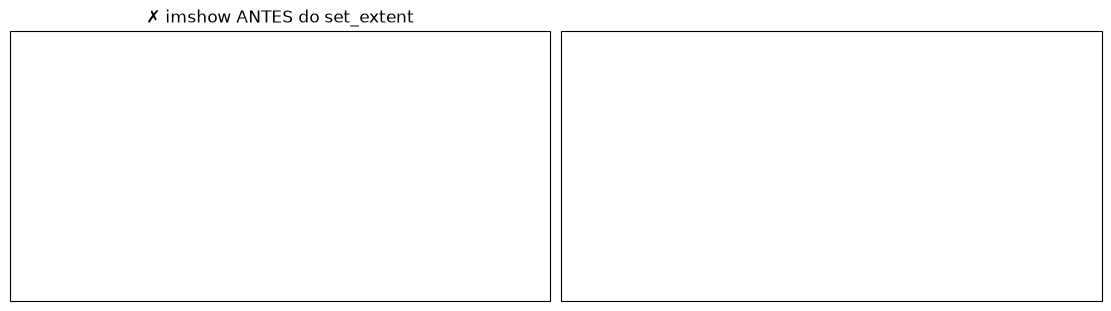

In [22]:
#| label: fig-raster-reproj
#| fig-cap: "Mesmo raster sintético, mesma projeção de destino (RotatedPole) — a diferença entre os dois painéis é só a ORDEM de chamada do set_extent()."

img = np.linspace(0, 1, 10_000).reshape(100, 100)

img_extent = (-49.5, -48.0, -28.2, -27.0)  # bbox perto de Florianópolis/SC
img_proj = ccrs.PlateCarree()

map_proj = ccrs.RotatedPole(pole_longitude=120.0,                           pole_latitude=70.0
)
map_extent = (-50.0, -47.5, -28.6, -26.6)

fig, axs = plt.subplots(
    1, 2, figsize=(11, 5), subplot_kw={"projection": map_proj},
    sharex=True, sharey=True, layout="constrained",
)

axs[0].set_title("✗ imshow ANTES do set_extent")
axs[0].imshow(img, extent=img_extent, 
                    origin="lower", transform=img_proj, 
                    cmap="viridis"
                    )
axs[0].set_extent(map_extent, 
                crs=img_proj
                )

axs[1].set_title("✓ imshow DEPOIS do set_extent")
axs[1].set_extent(map_extent, 
                    crs=img_proj
                    )
axs[1].imshow(img, extent=img_extent, origin="lower", transform=img_proj, cmap="viridis")

for ax in axs:
    ax.coastlines(linewidth=0.6)
    ax.gridlines(draw_labels=False, linewidth=0.3)

plt.show()

## SIRGAS - Padrão Brasileiro

**SIRGAS2000** (Sistema de Referência Geocêntrico para as Américas) é o datum oficial do Brasil desde 2005 (IBGE), substituindo os antigos SAD69 e Córrego Alegre. É geocêntrico, compatível com GPS/WGS84 na prática (as diferenças são de centímetros, não de metros), e é o que toda base oficial do IBGE — incluindo os dados do `geobr` que usamos nos notebooks anteriores, já vem por padrão (`EPSG:4674`).

Como o Brasil é largo demais pra uma única zona UTM, o território é coberto por várias zonas SIRGAS2000/UTM, uma a cada 6° de longitude. Da mesma forma que existe WGS84/UTM também existe SIRGAS2000/UTM, como formas projetadas do sistema de referencia. 

Abaixo, vamos colorir cada estado pela UTM de seu centróide. 

In [ ]:
#| label: fig-utm-zones
#| fig-cap: "Estados brasileiros coloridos pela zona UTM do centroide de cada um, com as linhas tracejadas marcando os limites de cada zona (meridianos a cada 6°). Note como estados largos (como o Amazonas) cruzam mais de uma zona -- na prática, escolhe-se a zona mais próxima do centro da área de interesse."

states = geobr.read_state(year=2020)
states["utm_zone"] = states.geometry.centroid.x.apply(lambda lon: int((lon + 180) // 6) + 1)

fig, ax = plt.subplots(figsize=(7, 8))
states.plot(
    ax=ax,
    column="utm_zone",
    categorical=True,
    cmap="tab10",
    edgecolor="white",
    linewidth=0.6,
    legend=True,
    legend_kwds={"title": "Zona UTM", "loc": "lower left"},
)

minx, miny, maxx, maxy = states.total_bounds
zone_min, zone_max = int(states["utm_zone"].min()), int(states["utm_zone"].max())
for zone in range(zone_min, zone_max + 2):
    lon = -180 + 6 * (zone - 1)  # limite oeste da zona
    if minx - 1 <= lon <= maxx + 1:
        ax.axvline(lon, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
        if lon < maxx:
            ax.text(lon + 0.3, maxy + 0.3, f"{zone}", fontsize=8, ha="left", va="bottom")

ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1.5)
ax.set_title("Zonas UTM por estado", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

## Outras Grades Modernas

Existem muito outros grids que surgem como solução para problemas práticos. Um desses é o H3 hexágonos criado pela Uber, que se espalhou como um grid padrão para análises dinâmicas de preço e ta ganhando muita aquisição pela comunidade geoespacial. 


::: {.callout-note appearance="simple"}
A partir do minuto 9:30 nesse [https://www.youtube.com/watch?v=ay2uwtRO3QE&t=573s](https://www.youtube.com/watch?v=ay2uwtRO3QE&t=573s) esse software engineer da Uber discute sobre como chegaram a solução de hexágonos como forma padrão dos grids da Uber.
:::
###  Hexágonos - H3

Ao invés de grades quadradas com 4 vizinhos, hexágonos apresentam uma solução para esse problema pertinente. De tal forma como a hipotenusa sempre sendo  maior que os catetos, num hexágono todos as distâncias são uniformes entre cada lado. Cada héxagono tem 6 vizinhos, todos a mesma distância do centro. 
É por isso que virou padrão da indústria pra coisas como precificação dinâmica, densidade de corridas e qualquer análise espacial em escala.

"Squares (like geohash or quadtree grids) have uneven neighbor distances and distort heavily as you move across the map, especially near poles"

In [ ]:
from matplotlib.patches import Rectangle, RegularPolygon

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Grade quadrada ---
ax = axes[0]
s = 1.0
for i in range(-2, 3):
    for j in range(-2, 3):
        color = "#f0f0f0" if (i, j) != (0, 0) else "#e63946"
        ax.add_patch(Rectangle((i - s/2, j - s/2), s, s,
                                facecolor=color, edgecolor="white", linewidth=1.5))

orth = [(1, 0), (-1, 0), (0, 1), (0, -1)]
diag = [(1, 1), (1, -1), (-1, 1), (-1, -1)]

for dx, dy in orth:
    ax.plot([0, dx], [0, dy], color="#457b9d", linewidth=2.5, zorder=3)
for dx, dy in diag:
    ax.plot([0, dx], [0, dy], color="#f4a261", linewidth=2.5, zorder=3)

ax.plot(0, 0, "o", color="white", markersize=6, zorder=4)
ax.annotate("1.0", xy=(0.55, 0.08), color="#457b9d", fontsize=11, fontweight="bold")
ax.annotate("√2 ≈ 1.41", xy=(0.55, 0.62), color="#f4a261", fontsize=11, fontweight="bold")

ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Grade quadrada — 2 distâncias diferentes", fontsize=11, fontweight="bold")

# --- Grade hexagonal ---
ax = axes[1]
R = 1.0
offsets_axial = [(1, 0), (1, -1), (0, -1), (-1, 0), (-1, 1), (0, 1), (0, 0)]

def axial_to_xy(q, r, size):
    x = size * np.sqrt(3) * (q + r / 2)
    y = size * 1.5 * r
    return x, y

centers = {(q, r): axial_to_xy(q, r, R) for q, r in offsets_axial}

for (q, r), (x, y) in centers.items():
    color = "#f0f0f0" if (q, r) != (0, 0) else "#e63946"
    hexagon = RegularPolygon((x, y), numVertices=6, radius=R,
                              orientation=0, facecolor=color,
                              edgecolor="white", linewidth=1.5)
    ax.add_patch(hexagon)

cx, cy = centers[(0, 0)]
for (q, r), (x, y) in centers.items():
    if (q, r) != (0, 0):
        ax.plot([cx, x], [cy, y], color="#457b9d", linewidth=2.5, zorder=3)

ax.plot(cx, cy, "o", color="white", markersize=6, zorder=4)
dist = np.sqrt(3) * R
ax.annotate(f"{dist:.2f} (sempre)", xy=(cx + 0.25, cy - 1.65), color="#457b9d",
            fontsize=11, fontweight="bold")

ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Grade hexagonal — 1 distância única", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

Hexagons minimize these distortions, preserve area more uniformly, avoid diagonal inconsistencies, and produce cleaner, more natural-looking spatial clusters  

É essa uniformidade de distância — e não só a estética do hexágono — que faz o H3 ser melhor pra análises de vizinhança, roteamento e agregação espacial: a Uber não precisa se preocupar em "corrigir" a distância dependendo de qual dos vizinhos está sendo comparado.

In [ ]:
#| label: fig-h3
#| fig-cap: "Porto Alegre coberta por hexágonos H3, resolução 8 (~0.7 km² por hexágono)."

muni = geobr.read_municipality(code_muni=4314902, year=2020)  # Porto Alegre
geom = muni.geometry.iloc[0]

shape = h3.geo_to_h3shape(geom)
cells = h3.h3shape_to_cells(shape, 8)

hex_polygons = [
    Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
    for cell in cells
]
hex_gdf = gpd.GeoDataFrame({"h3_cell": list(cells)}, geometry=hex_polygons, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(7, 7))
muni.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=1)
hex_gdf.plot(ax=ax, facecolor="none", edgecolor="#e63946", linewidth=0.5)
ax.set_title(f"Porto Alegre em {len(hex_gdf)} hexágonos H3 (res. 8)", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

Cada hexágono tem um índice único (`h3_cell`, tipo `88a91bcd51fffff`) que serve como chave pra agregação espacial, só que numa grade uniforme em vez dos limites do IBGE.

### H3 interativo

Um mapa estático mostra a malha, mas esconde como o H3 pode ser útil na prática, onde cada célula é um índice individual em diferentes niveis. Com `folium` (que embrulha a biblioteca JS [Leaflet](https://leafletjs.com/)) dá pra gerar um mapa interativo, passe o mouse sobre qualquer hexágono e veja seu `h3_cell` e uma métrica calculada célula a célula.

Vamos cobrir **Catolé do Rocha**, no sertão da Paraíba.

In [ ]:
#| label: fig-h3-folium
#| fig-cap: "Catolé do Rocha (PB) coberta por hexágonos H3, resolução 8. Passe o mouse sobre qualquer hexágono pra ver seu índice e a distância até o centro do município."

import folium
import branca.colormap as cm

muni = geobr.read_municipality(code_muni=2504306, year=2020)  # Catolé do Rocha - PB
geom = muni.geometry.iloc[0]
centroid = geom.centroid

shape = h3.geo_to_h3shape(geom)
cells = h3.h3shape_to_cells(shape, 8)

hex_polygons = [
    Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
    for cell in cells
]
hex_gdf = gpd.GeoDataFrame({"h3_cell": list(cells)}, geometry=hex_polygons, crs="EPSG:4326")

# distância de cada centro de hexágono até o centro do município (~km, aproximando 1° ≈ 111km)
hex_gdf["dist_km"] = hex_gdf.geometry.centroid.apply(lambda p: centroid.distance(p) * 111).round(2)

colormap = cm.linear.YlOrRd_09.scale(hex_gdf["dist_km"].min(), hex_gdf["dist_km"].max())
colormap.caption = "Distância ao centro do município (km)"

m = folium.Map(location=[centroid.y, centroid.x], zoom_start=12, tiles="cartodbpositron")

folium.GeoJson(
    muni,
    style_function=lambda _: {"fillOpacity": 0, "color": "#333333", "weight": 2},
).add_to(m)

folium.GeoJson(
    hex_gdf,
    style_function=lambda feat: {
        "fillColor": colormap(feat["properties"]["dist_km"]),
        "color": "white",
        "weight": 0.6,
        "fillOpacity": 0.75,
    },
    highlight_function=lambda _: {"weight": 2, "color": "black"},
    tooltip=folium.GeoJsonTooltip(
        fields=["h3_cell", "dist_km"],
        aliases=["Célula H3:", "Distância ao centro (km):"],
        localize=True,
    ),
).add_to(m)

colormap.add_to(m)
m

Repare que a métrica (`dist_km`) foi calculada uma vez por célula e vive junto com o `h3_cell` no `GeoDataFrame` — é exatamente assim que se agrega qualquer variável (densidade populacional, corridas de app, chamadas de emergência...) numa grade H3, uma linha por célula, um índice, um valor.

::: {.callout-note appearance="simple"}
## Tarefa: monte seu próprio mapa de hexágonos

Escolha uma das cidades abaixo (ou outra à sua escolha — busque o `code_muni` no [IBGE](https://www.ibge.gov.br/explica/codigos-dos-municipios.php) ou filtrando `geobr.read_municipality()` pelo nome, como fizemos em @fig-utm-zones) e repita o processo acima:

| Cidade | UF | `code_muni` |
|---|---|---|
| Bonito | MS | 5002308 |
| Paraty | RJ | 3303807 |
| Lençóis | BA | 2919207 |
| Bento Gonçalves | RS | 4302105 |

1. Baixe o polígono do município com `geobr.read_municipality(code_muni=..., year=2020)`.
2. Gere as células com `h3.geo_to_h3shape()` e `h3.h3shape_to_cells()` — teste resoluções diferentes (7, 8, 9) e observe como o número de células muda.
3. Calcule uma métrica por célula: pode ser a distância ao centro (como aqui), a área de cada hexágono, ou até um valor aleatório simulando "densidade".
4. Monte o mapa com `folium.GeoJson()` e um `GeoJsonTooltip` mostrando `h3_cell` e a métrica escolhida.

Compare com um colega que escolheu outra cidade: o número de hexágonos muda muito entre uma cidade pequena e uma grande? E a resolução 9 ainda é viável pra um município enorme, ou o mapa fica pesado demais?
:::

## Referências

- Pebesma, E.; Bivand, R. — [Spatial Data Science, cap. 2: Spaces](https://r-spatial.org/book/02-Spaces.html)
- Lovelace, R.; Nowosad, J.; Muenchow, J. — [Geocomputation with R, cap. 7: Reprojecting geographic data](https://r.geocompx.org/reproj-geo-data)
- Cartopy gallery — [Gridlines and tick labels](https://cartopy.readthedocs.io/stable/gallery/gridlines_and_labels/gridliner.html)
- Cartopy gallery — [Raster reprojections](https://cartopy.readthedocs.io/stable/gallery/scalar_data/raster_reprojections.html)
- [H3 — Uber's Hexagonal Hierarchical Spatial Index](https://h3geo.org/)
- Uber - [Uber Blog - Dynamic Prices](https://www.uber.com/us/en/blog/h3/)

---

# Análise Espacial de Dados Vetoriais
### Relações topológicas, distância, joins espaciais e agregação

*Emanuel Goulart — today*


In [ ]:
#| include: false
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geobr
import osmnx as ox
import h3
from shapely.geometry import Polygon
from shapely.affinity import rotate, scale



## Análise Espacial em Dados Vetoriais

Esse notebook explora as operações espaciais mais usadas no dia a dia como as relações topológicas, distância, joins espaciais, agregação, zoneamento e transformações geométricas.

Para o nosso estudo de casa, vamos utilizar a cidade de *Sinop* no *Mato Grosso*, combinando duas fontes de dados:

- **`geobr`** — escolas (INEP) e estabelecimentos de saúde (CNES), dados oficiais e já geolocalizados.
- **OpenStreetMap** (via `osmnx`) — a malha viária, para explorar interseções e conectividade.

::: {.callout-note appearance="simple"}
Escolhemos Sinop meio que arbitrariamente, é uma cidade média, longe do eixo Rio-São Paulo que domina a maioria dos exemplos de GIS por aí. Sinta-se livre pra trocar o `code_muni` abaixo pela sua própria cidade e rodar tudo de novo.
:::

In [ ]:
code_muni = 5107909  # Sinop, MT
CRS_PROJETADO = "EPSG:31981"  # SIRGAS2000 / UTM zone 21S -- cobre o MT ocidental

sinop = geobr.read_municipality(code_muni=code_muni, year=2020)
schools = geobr.read_schools(year=2020, code_muni=code_muni)
health = geobr.read_health_facilities(date=202304, code_muni=code_muni)

# versões já projetadas (metros) -- reaproveitadas no notebook inteiro
sinop_proj = sinop.to_crs(CRS_PROJETADO)
schools_proj = schools.to_crs(CRS_PROJETADO)
health_proj = health.to_crs(CRS_PROJETADO)

print(f"{len(schools)} escolas, {len(health)} estabelecimentos de saúde")

In [ ]:
#| label: fig-overview
#| fig-cap: "Sinop, MT: escolas (INEP) e estabelecimentos de saúde (CNES)."

fig, ax = plt.subplots(figsize=(7, 7))
sinop.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
health.plot(ax=ax, markersize=6, color="#2a78d6", alpha=0.5, label="Saúde (CNES)")
schools.plot(ax=ax, markersize=10, color="#e63946", alpha=0.8, label="Escolas (INEP)")
ax.legend(loc="lower left")
ax.set_title("Sinop, MT", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

## Operações Geométricas

Operações geométricas refere-se a um conjunto de métodos que são utlizados para analisar e processar feições geométricas. Ele portanto corrobora em responder como dois ou mais objectos geograficos se relacionam entre si? eles se sobrepoem? se tocam? alguma intersecção? quão longe estão entre eles? 

### Centroid

Centroide é o centro de massa da geometria, seja ela linha, polígono ou geometry collection. Extrair esse centróide é muito útil em diversos casos, como por exemplo para localizar 'labels' na figura, para servir de base em operações espaciais de outros polígonos e etc. Se você tentar calcular o centróide em um CRS não projetado, geopandas calcula mesmo assim, mas avisa que o resultado pode estar errado: grau não é uma unidade de distância uniforme, então o "centro de massa" calculado direto em lat/lon fica levemente deslocado do centro geométrico real. Os dados precisam estar projetados em um sistema de coordenadas projetado (UTM por exemplo) pra esse cálculo fazer sentido de verdade.

In [ ]:
#| label: fig-centroid-d
#| fig-cap: "Centroide do polígono de Sinop (estrela) e centro geométrico da distribuição de escolas (triângulo) -- ambos calculados já em CRS projetado."

centroide_sinop = sinop_proj.geometry.centroid.iloc[0]
centro_escolas = schools_proj.geometry.union_all().centroid

# de volta pro CRS geográfico só pra plotar junto com o resto
centroide_sinop_geo = gpd.GeoSeries([centroide_sinop], crs=CRS_PROJETADO).to_crs(sinop.crs).iloc[0]
centro_escolas_geo = gpd.GeoSeries([centro_escolas], crs=CRS_PROJETADO).to_crs(sinop.crs).iloc[0]

fig, ax = plt.subplots(figsize=(7, 7))
sinop.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
schools.plot(ax=ax, markersize=6, color="#e63946", alpha=0.35, label="Escolas (INEP)")
ax.scatter(centroide_sinop_geo.x, centroide_sinop_geo.y, marker="*", s=280,
           color="#2a78d6", edgecolor="black", linewidth=0.5, zorder=5, label="Centroide do município")
ax.scatter(centro_escolas_geo.x, centro_escolas_geo.y, marker="^", s=140,
           color="#e63946", edgecolor="black", linewidth=0.5, zorder=5, label="Centro das escolas")
ax.legend(loc="lower left")
ax.set_title("Centroide vs. centro geométrico da distribuição", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

In [ ]:
#| label: fig-centroid
#| fig-cap: "Centroide dos municipios de mato grosso"

muni = geobr.read_municipality(year=2020)

# projetando no SIRGAS 2000 UTM 23 S
muni = muni.to_crs('EPSG:31983')
muni_mt = muni.loc[muni['abbrev_state']=='MT']

## project to UTM 22S
muni_mt['centroide'] = muni_mt.geometry.centroid

fig, ax = plt.subplots(figsize=(7,7))
muni_mt.plot(ax=ax)
muni_mt.geometry.centroid.plot(ax=ax,color="#7c2b2b")
ax.set_axis_off()
ax.set_title('Municípios de MT e seus respectivos centróide')
plt.show()

### União e Dissolve

Algumas operações serve para unir as geometrias ou dissolve-las a um nível de agregação para formar outros. Você pode dissolver as geometrias das cidades para formar um estado ou região, por exemplo. Olhando de perto, `union_all()` funde todas as geometrias em única geometria. Ele faz isso sem olhar pra nenhum atributo. Já o `dissolve(by=...)` faz a mesma fusão por baixo dos panos, mas primeiro agrupa as linhas pelo dado atributo. As duas funções tem como parâmetro o método `method`: `"unary"` (padrão, robusto, funciona mesmo com geometrias sobrepostas) ou `"coverage"` ,bem mais rápido, mas só vale pra polígonos que já formam uma cobertura sem sobreposição, tipo limites administrativos vizinhos, se você usa as geometrias do CAR aqui vai ser encrenca.

In [ ]:
#| label: fig-dissolve
#| fig-cap: "Área de influência (buffer de 400 m) de cada escola, no núcleo urbano de Sinop. À esquerda, union_all() funde tudo numa geometria só. À direita, dissolve(by='rede') agrupa antes de unir, preservando a rede de ensino."

dependencia_map = {1: "Federal", 
                    2: "Estadual",
                     3: "Municipal", 
                     4: "Privada"}
schools_proj["rede"] = schools_proj["tp_dependencia"].map(dependencia_map)

influencia = schools_proj[["rede", 
                            "geometry"]].copy()
influencia["geometry"] = influencia.buffer(400)

uniao_total = influencia.union_all()

# aqui dissolvendo pelos tipos de escola
dissolve_por_rede = influencia.dissolve(by="rede").reset_index()

# os buffers (400 m) somem de vista numa figura do município inteiro (~60 km) --
# damos zoom no maior "blob" resultante da união, que é exatamente o núcleo
# urbano denso (as escolas isoladas na zona rural viram círculos minúsculos à parte)
maior_blob = max(uniao_total.geoms, key=lambda g: g.area)
minx, miny, maxx, maxy = maior_blob.bounds
folga = 500

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax in axes:
    sinop_proj.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.6)
    ax.set_xlim(minx - folga, maxx + folga)
    ax.set_ylim(miny - folga, maxy + folga)
    ax.set_axis_off()

gpd.GeoSeries([uniao_total], crs=CRS_PROJETADO).plot(ax=axes[0], color="#e63946", alpha=0.6)
axes[0].set_title("Union All")

dissolve_por_rede.plot(ax=axes[1], column="rede", categorical=True, cmap="Set2",
                        alpha=0.75, legend=True, legend_kwds={"title": "Rede", "loc": "lower left"})
axes[1].set_title("Dissolve by Tipos de Escola")

plt.tight_layout()
plt.show()

### Buffer

Buffer é uma operação geométrica que cria uma zona ao redor de uma dada geometria, geralmente representando uma distância (raio de cobertura, zona de segurança, área de influência). Combinar buffer com interseção responde perguntas do tipo "que áreas estão cobertas mais de uma vez?" — por exemplo, existe algum ponto em Sinop dentro do raio de 1 km de *duas* escolas ao mesmo tempo?

In [ ]:
#| label: fig-buffer-overlap
#| fig-cap: "Buffer de 1 km ao redor de cada escola, no núcleo urbano de Sinop. Em vermelho, as regiões cobertas por duas ou mais escolas ao mesmo tempo."

buffers = schools_proj[["code_school", "geometry"]].copy()
buffers["geometry"] = buffers.buffer(1000)  # 1 km de raio

# cruza os buffers com eles mesmos; code_school_1 < code_school_2 evita
# contar a interseção de um buffer com ele mesmo e duplicar cada par (A∩B == B∩A)
pares = gpd.overlay(buffers, buffers, how="intersection")
pares = pares[pares["code_school_1"] < pares["code_school_2"]]
cobertura_dupla = pares.union_all()

# zoom na região onde as sobreposições acontecem, em vez do município (~60 km) inteiro
# minx, miny, maxx, maxy = cobertura_dupla.bounds
# folga = 1500

fig, ax = plt.subplots(figsize=(7, 7))
sinop_proj.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
buffers.plot(ax=ax, color="#2a78d6", alpha=0.15, edgecolor="#2a78d6", linewidth=0.4)
gpd.GeoSeries([cobertura_dupla], crs=CRS_PROJETADO).plot(ax=ax, color="#e63946", alpha=0.6)
schools_proj.plot(ax=ax, markersize=8, color="black")
# ax.set_xlim(minx - folga, maxx + folga)
# ax.set_ylim(miny - folga, maxy + folga)
ax.set_title(f"{len(pares)} pares de escolas com buffer sobreposto (raio 1 km)", fontsize=11, fontweight="bold")
ax.set_axis_off()
plt.show()

::: {.callout-tip appearance="simple"}
Um buffer em escala de cidade fica na casa das centenas de metros a poucos quilômetros — 1000 km cobriria o Mato Grosso inteiro (e boa parte dos estados vizinhos) várias vezes. Troque o raio em `buffers.buffer(...)` (em metros, já que estamos em CRS projetado) e rode de novo pra ver como o número de pares sobrepostos muda.
:::

### Convex Hull

O convex hull é o menor polígono convexo que contém todos os pontos de um conjunto — imagine esticar um elástico em volta de todos os pontos e deixar ele encolher até tocar só nos mais externos. Vamos ilustrar isso a partir dos pontos das escolas de Sinop.

In [ ]:
#| label: fig-convex-hull
#| fig-cap: "Convex hull das escolas de Sinop: o menor polígono convexo que contém todos os pontos."

hull = schools_proj.geometry.union_all().convex_hull

fig, ax = plt.subplots(figsize=(7, 7))
sinop_proj.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)
gpd.GeoSeries([hull], crs=CRS_PROJETADO).plot(ax=ax, color="#f4a261", alpha=0.4, edgecolor="#e76f51", linewidth=1.2)
schools_proj.plot(ax=ax, markersize=10, color="#e63946", label="Escolas (INEP)")
ax.legend(loc="lower left")
ax.set_title("Convex hull das escolas de Sinop", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

## Relações topológicas

Relações topológicas servem para compreender como duas geometrias se relacionam no espaço: `intersects` (encosta em qualquer parte), `within` (está totalmente dentro), `touches` (encosta só na borda, sem sobrepor), `disjoint` (não tem relação nenhuma). Repare que `intersects` é simétrica (se X intersecta Y, Y intersecta X), mas `within`/`contains` não são.

Vamos usar isso pra classificar as escolas de Sinop em **urbanas** (dentro de um raio de 2,5 km do centro) e **rurais** (fora dele).

In [ ]:
# estabelecendo um ponto no centro de Sinop
centro = gpd.GeoSeries(
    [gpd.points_from_xy([-55.5089], [-11.8642])[0]], crs="EPSG:4326"
).to_crs(CRS_PROJETADO)

area_urbana = centro.buffer(5000).iloc[0]  # 5 km, já em metros

## aqui a analise topologica
## se a escola esta dentro da area urbana ( nosso buffer the 5km) entao urbana, senao rural 
schools_proj["zona"] = np.where(schools_proj.within(area_urbana), "urbana", "rural")

# printa o numero de escolas na area urbana 
print(schools_proj["zona"].value_counts())

In [ ]:
## Agora vamos plots 
fig, ax = plt.subplots(figsize=(7, 7))

# delineacao do municipio 
sinop.plot(ax=ax, color="#f0f0f0", edgecolor="#898781", linewidth=0.8)

# area_urbana é um shapely Polygon "puro", não um GeoDataFrame
# por isso não tem .plot(); e está em CRS_PROJETADO (metros), então reprojetamos de volta
# pro CRS geográfico de sinop/schools/health antes de plotar, senão as escalas não batem
area_urbana_geo = gpd.GeoSeries([area_urbana], 
                    crs=CRS_PROJETADO).to_crs(sinop.crs).iloc[0]
# o truque pra quando nao eh geopandas, ou entao converta para geopandas
ax.fill(*area_urbana_geo.exterior.xy, 
            color="#cdea0eb9",          
          edgecolor="#d4caa7", 
            linewidth=0.6)

health.plot(ax=ax, markersize=6, color="#2a78d6", alpha=0.5, label="Saúde (CNES)")

schools.plot(ax=ax, markersize=10, color="#e63946", alpha=0.8, label="Escolas (INEP)")
ax.legend(loc="lower left")
ax.set_title("Sinop, MT", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.show()

::: {.callout-note appearance="simple"}
Não mosca!

Se você ainda não está a vontade com as relações topológicas, então da uma olhada na nossa aula de python+GIS, onde olhamos com muito mais calma e a fundo essas relações. Aula 1 e Aula 2. [Python+GIS](https://github.com/ftl-brazil-2026/gis-python-basics/blob/main/python_gis_1.ipynb)
:::

## Relações de distância

Diferente das relações topológicas que são por natureza boleanas (verdadeiro/falso), relações de **distância** são contínuas. Além disso, existem algumas nuances que precisam ser consideradas dependendo do tipo de vetor que estamos analisando. Certamento a distancia entre dois points é a famosa distância euclideana, muito já batida e amassada pela algebra linear.

![Source:Wikipedia - Euclidean Distance](images/Euclidean_distance_2d.svg){fig-align="center"}

Contudo, observamos a distancia entre duas retas, ou a distancia entre um ponto e um polígono, e então a nuance toma conta. Vamos considerar que a distância entre um ponto e um polígono mais próximas entre os dois elementos. 

![Source:Arcgis - Arcmap Documentacao](images/GUID-6FD5566F-FE23-4289-AA6D-AC1A6CA0CF6E-web.png){fig-align="center"}



Mão na massa: **qual a distância de cada escola até o estabelecimento de saúde mais próximo?**

In [ ]:
## Importante aqui, olha para a reducao utilizando o minimo
dist_para_saude = schools_proj.geometry.apply(
    lambda pt: health_proj.distance(pt).min()
)

print(f"Distância média até a saúde mais próxima: {dist_para_saude.mean():.0f} m")
print(f"Escola mais isolada: {dist_para_saude.max():.0f} m")
print(f"Escola mais proxima: {dist_para_saude.min():.0f} m")

### Transformações afins

Rotação, escala, translação e cisalhamento — operações que distorcem uma geometria sem recalcular nada a partir dos dados originais, só aplicando uma matriz na geometria já existente. Útil pra ajustar geometrias mal-alinhadas ou simplesmente pra entender o que cada operação faz:

In [ ]:
#| label: fig-affine
#| fig-cap: "A mesma geometria (limite de Sinop): original, rotacionada 45° e escalada pela metade — sempre em torno do próprio centro."

geom = sinop_proj.geometry.iloc[0]

geom_rotacionada = rotate(geom, 45, origin="centroid")
geom_escalada = scale(geom, xfact=0.5, yfact=0.5, origin="centroid")

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, g, title in zip(
    axes, [geom, geom_rotacionada, geom_escalada], ["Original", "Rotação 45°", "Escala 0.5x"]
):
    gpd.GeoSeries([geom], crs=CRS_PROJETADO).boundary.plot(ax=ax, color="#dcdad2", linewidth=0.8)
    gpd.GeoSeries([g], crs=CRS_PROJETADO).plot(ax=ax, color="#e63946", alpha=0.6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## Joins espaciais por distância

Um **join espacial** funciona como um join de atributos (tema batido para quem conhece tabelas relacionais), só que o critério de join é uma relação espacial em vez de uma chave em comum. `sjoin_nearest` responde a pergunta do capítulo anterior, mas devolve um `GeoDataFrame` já unido, com a opção de limitar a um raio máximo (`max_distance`), o que é útil pra não juntar pontos longe demais de fazer sentido:

In [ ]:
schools_com_saude = gpd.sjoin_nearest(
    schools_proj,
    health_proj[["geometry", "no_fantasia"]],
    distance_col="dist_saude_mais_proxima",
    max_distance=5000,  # não junta nada além de 5 km
)

schools_com_saude[["name_school", "no_fantasia", "dist_saude_mais_proxima"]].sort_values(
    "dist_saude_mais_proxima", ascending=False
).head(5)

## Agregação espacial

**Agregação espacial** resume valores de um objeto (o "alvo") agrupando pela geometria de outro (a "fonte").  A geometria da fonte é quem define os grupos, e o resultado herda a geometria *dela*, não a do alvo. Vamos agregar pelo grupo mais simples que já temos: urbana vs. rural.

In [ ]:
resumo_zona = (
    schools_com_saude
    .groupby("zona")
    .agg(
        n_escolas=("code_school", "count"),
        dist_media_saude=("dist_saude_mais_proxima", "mean"),
        dist_max_saude=("dist_saude_mais_proxima", "max"),
        # faca aqui a minima distancia 
    )
    .round(0)
)
resumo_zona

A partir da nossa análise espacial, concluímos que no munícipio de Sinop, as escolas rurais estão, em média, bem mais longe do estabelecimento de saúde mais próximo. Em média, caso um acidente num ambiente escolar aconteça, as escolas da área rural estão a pelo menos 700 metros a mais de uma unidade de saúde comparado as escolas numa área urbana. Esse tipo de análise, é possível quando elencamos nosso conhecimento em manipulação dos dados espaciais: Topologia, Geopandas, transformações, projeções, buffers, análise de distância e agregações espaciais. 

Algumas questões que pairam no ar? Como conseguimos analisar as densidades espaciais e entender a respeito de demanda? proximidade? 

O ecossistema geoespacial nos permite ir muito mais além, e veremos isso com mais calma na nossa próxima aula. 


## Referências

- Lovelace, R.; Nowosad, J.; Muenchow, J. — [Geocomputation with R, cap. 8: Spatial operations](https://r.geocompx.org/spatial-operations#spatial-aggr)
- [geobr](https://github.com/ipea/geobr) — dados oficiais geolocalizados do Brasil (IBGE, INEP, CNES)
- [OSMnx](https://osmnx.readthedocs.io/) — download e análise de redes urbanas do OpenStreetMap
- [H3 — Uber's Hexagonal Hierarchical Spatial Index](https://h3geo.org/)
- [IPEA Data](http://www.ipeadata.gov.br/) — séries históricas socioeconômicas do Brasil